# NB19 — Hospital Profit Margin (operating-margin / profitability factor)

**Second spread-driver in the five-factor decomposition (Decision 43):** equipment · overhead · labor set the *floor*; **profit margin** and insurance negotiation set the *spread*. NB16 covered insurance negotiation at the **procedure** level (markup over the Medicare floor). **NB19 covers profit margin at the *hospital* level.**

> **HARD RULE — Decision 44.** A hospital-wide operating margin is **NOT** a per-procedure margin. NB19 characterizes *overall* profitability; it must never be presented as "the profit on a 73721." The two lenses (NB16 procedure-markup, NB19 hospital-margin) feed the app *side by side*, never merged. The integrity guard (Step I) enforces this: no margin record may carry a CPT.

**Sourcing discipline (standing rules):** two-flag every value (`corroborated` / `confirmed`); NaN sentinels, never fabricated fills; `[SYNTHETIC DATA]` stamp for fabricated outputs, "DRAFT — NOT PUBLISHABLE" for real-but-gated; all publish decisions route through one `is_publishable()` chokepoint. Verify source lines against the file's own layout before flipping `source_confirmed=True` (the NB15 lesson).

**Standard mold:** Step 0 path → 1 roster / source-map / slots → 2 compute + contract → 3 synthetic smoke → R real → S sensitivity → V chart → F handoff (`NB19_MARGIN`) → I integrity.


## Step 0 — Path resolver

ROOT walk-up on `src/queries.py` from `notebooks/` (same resolver as NB16–NB18). Print the chosen ROOT and confirm `outputs/` exists. No DB work here — NB19's real data is manual (HCRIS/990), not a DuckDB pull.


In [1]:
# ── NB19 · Step 0 — Path resolver ─────────────────────────────────────────────
# Resolves ROOT by walking up until a directory actually contains the project
# anchor (src/queries.py) — works whether the kernel's cwd is ROOT or notebooks/.
# No DB work here: NB19's real data (HCRIS cost report / IRS 990) is a manual
# download, not a DuckDB pull. This cell only pins paths + a run-order helper.
import sys
from pathlib import Path

ANCHOR = Path("src") / "queries.py"        # same anchor NB16–NB18 use

def _resolve_root(start: Path) -> Path:
    """Walk up from `start` until a directory contains src/queries.py."""
    for cand in [start, *start.parents]:
        if (cand / ANCHOR).exists():
            return cand
    return start                            # fall back to cwd; reported loudly below

_cwd = Path.cwd().resolve()
ROOT = _resolve_root(_cwd)
ANCHOR_FOUND = (ROOT / ANCHOR).exists()

# Keep the family convention: ROOT (not src/) on sys.path, canonical form is
# `from src import queries`. NB19 may not need it, but stay consistent.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Output dir for the Step-F handoff (outputs/nb19_margin.json).
OUTPUTS_DIR = ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

def require(name: str, hint: str = "") -> None:
    """Fail with a clear message (not a bare NameError) if an upstream cell
    didn't run. Run-order NameErrors are the known failure mode here — the
    canonical run mode is Restart & Run All."""
    if name not in globals():
        msg = f"[NB19] '{name}' is not defined — run upstream cells first (Restart & Run All)."
        if hint:
            msg += f"  Hint: {hint}"
        raise NameError(msg)

print("NB19 · Step 0 — path resolver")
print(f"  cwd          : {_cwd}")
print(f"  ROOT         : {ROOT}")
print(f"  anchor found : {ANCHOR_FOUND}  ({ANCHOR})")
print(f"  outputs dir  : {OUTPUTS_DIR}  (exists: {OUTPUTS_DIR.exists()})")
print(f"  sys.path[0]  : {sys.path[0]}")
print("  ✓ ROOT resolved cleanly." if ANCHOR_FOUND
      else "  ⚠ anchor NOT found — ROOT fell back to cwd; check the kernel's working directory.")

NB19 · Step 0 — path resolver
  cwd          : C:\Users\kedha\Documents\dfw-hospital-pricing\notebooks
  ROOT         : C:\Users\kedha\Documents\dfw-hospital-pricing
  anchor found : True  (src\queries.py)
  outputs dir  : C:\Users\kedha\Documents\dfw-hospital-pricing\outputs  (exists: True)
  sys.path[0]  : C:\Users\kedha\Documents\dfw-hospital-pricing
  ✓ ROOT resolved cleanly.


## Step 1 — Roster, ownership, data-source map, ingestion slots

**Roster** (CCNs verified) — ownership is the axis this factor is read against:

| Hospital | CCN | Ownership | County |
|---|---|---|---|
| Baylor UMC | 450021 | nonprofit | Dallas |
| Methodist Dallas | 450051 | nonprofit | Dallas |
| Parkland | 450015 | public | Dallas |
| MCA / Medical City Alliance | 670103 | for-profit (HCA) | Tarrant |
| THP Plano | 450771 | nonprofit | Collin |

**Data-source map** — the honest "common denominator vs. supplement" split:

- **HCRIS — CMS-2552-10 cost report** (the *spine*; CCN-keyed; filed by **all five**, all Medicare-participating).
  - Operating margin ≈ (net patient revenue − total operating expenses) / total operating revenue.
  - **Worksheet G-3** = Statement of Revenues and Expenses (net income line); **G-3 Line 3** = net patient revenue; **G-2 Line 43** = total operating expenses; **G-3 Line 5** = net revenue less operating expenses. *Confirm exact worksheet/line against the file layout before trusting — same discipline as the NB15 PUF layout tab (`source_confirmed=False` until then).*
- **IRS Form 990 + Schedule H** — the **three nonprofits only** (Baylor, Methodist, THP). Tax-return operating figures; cross-check against HCRIS.
- **HCA 10-K** — MCA is a *facility inside* HCA; the system reports at the corporate level, so **facility-level net income is not cleanly public** → MCA's margin comes from HCRIS, carried with an explicit comparability caveat.
- **Parkland CAFR / Dallas County financials** — public entity; audited annual report supplements HCRIS. Note the ~40% county tax appropriation lands in *non-operating* income (see Step 2 basis note).

**Sandbox reality:** HCRIS/990 live on cms.gov / IRS — unreachable from bash (same wall as the NB15 wage PUF; HCRIS numeric files are too large for Excel besides). Real values are a **manual download**; ingestion slots start as `None` with their schema in comments — *not fabricated*, wired at Step R. Expect **0/5 real** today, `source_confirmed=False`.


In [2]:
# ── NB19 · Step 1 — Roster, ownership, data-source map, ingestion slots ────────
require("ROOT", hint="run Step 0 first")
import math

# 1) ROSTER — CCNs verified; ownership is the axis this factor is read against.
ROSTER = {
    "Baylor":    {"ccn": "450021", "ownership": "nonprofit",  "county": "Dallas",
                  "name_full": "Baylor University Medical Center"},
    "Methodist": {"ccn": "450051", "ownership": "nonprofit",  "county": "Dallas",
                  "name_full": "Methodist Dallas Medical Center"},
    "Parkland":  {"ccn": "450015", "ownership": "public",     "county": "Dallas",
                  "name_full": "Parkland Health"},
    "MCA":       {"ccn": "670103", "ownership": "for-profit", "county": "Tarrant",
                  "name_full": "Medical City Alliance (HCA)"},
    "THP":       {"ccn": "450771", "ownership": "nonprofit",  "county": "Collin",
                  "name_full": "Texas Health Presbyterian Plano"},
}

# 2) DATA-SOURCE MAP — the honest "common denominator vs supplement" split.
#    source_confirmed stays False until the worksheet/line is eyeballed against
#    the file's OWN layout (the NB15 lesson — don't trust priors on line membership).
MARGIN_SOURCES = {
    "HCRIS": {
        "covers": ["Baylor", "Methodist", "Parkland", "MCA", "THP"],   # all five
        "keyed_by": "CCN", "form": "CMS-2552-10",
        "worksheet_lines": {
            "net_patient_revenue":      "G-3, line 3",
            "total_operating_expenses": "G-2, line 43",
            "net_rev_less_op_expenses": "G-3, line 5",
        },
        "note": "The spine: CCN-keyed, filed by all five (all Medicare-participating).",
        "source_confirmed": False,   # confirm G-3/G-2 lines against file layout first
    },
    "IRS_990_SCHED_H": {
        "covers": ["Baylor", "Methodist", "THP"],    # nonprofits only
        "keyed_by": "EIN", "form": "IRS Form 990 + Schedule H",
        "note": "Nonprofit tax-return operating figures; cross-check vs HCRIS.",
        "source_confirmed": False,
    },
    "HCA_10K": {
        "covers": ["MCA"],
        "keyed_by": "corporate (system-level)", "form": "HCA Healthcare 10-K",
        "note": "MCA is a facility inside HCA; facility net income is NOT cleanly "
                "public -> MCA margin comes from HCRIS, carried with a comparability caveat.",
        "source_confirmed": False,
    },
    "PARKLAND_CAFR": {
        "covers": ["Parkland"],
        "keyed_by": "public entity", "form": "Parkland/Dallas County audited annual report (CAFR)",
        "note": "~40% county tax appropriation lands in NON-operating income — "
                "operating vs total margin split matters most here (see Step 2).",
        "source_confirmed": False,
    },
}

# 3) INGESTION SLOTS — real margin values start empty (NaN), NOT fabricated.
#    Wired at Step R once the manual HCRIS/990 pull lands.
MARGIN_RECORD_FIELDS = [
    "hospital", "ccn", "ownership", "level",      # level == "hospital" (Decision 44)
    "margin", "basis", "fiscal_year", "source",   # the measured payload
    "corroborated", "confirmed",                  # two-flag sourcing
]

def _empty_slot(short):
    r = ROSTER[short]
    return {
        "hospital": short, "ccn": r["ccn"], "ownership": r["ownership"],
        "level": "hospital",           # NEVER per-procedure (Decision 44)
        "margin": float("nan"),        # NaN sentinel — nothing pulled yet
        "basis": None,                 # "operating" | "total", set at Step R
        "fiscal_year": None, "source": None,
        "corroborated": False, "confirmed": False,
    }

REAL_MARGIN = {short: _empty_slot(short) for short in ROSTER}

# ── self-report ───────────────────────────────────────────────────────────────
def _sources_for(short):
    return [sid for sid, s in MARGIN_SOURCES.items() if short in s["covers"]]

print("NB19 · Step 1 — roster, source map, ingestion slots\n")
print(f"{'Hospital':10} {'CCN':7} {'Ownership':11} {'County':8} Sources")
print("-" * 72)
for short, r in ROSTER.items():
    print(f"{short:10} {r['ccn']:7} {r['ownership']:11} {r['county']:8} "
          f"{', '.join(_sources_for(short))}")

n_filled = sum(1 for s in REAL_MARGIN.values() if not math.isnan(s["margin"]))
print(f"\nreal margin slots filled: {n_filled}/{len(REAL_MARGIN)}  "
      f"(expect 0/5 — manual HCRIS/990 pull not done)")
print("source_confirmed:", {sid: s['source_confirmed'] for sid, s in MARGIN_SOURCES.items()})
print("\n✓ roster + source map defined; all real slots NaN (not fabricated).")

NB19 · Step 1 — roster, source map, ingestion slots

Hospital   CCN     Ownership   County   Sources
------------------------------------------------------------------------
Baylor     450021  nonprofit   Dallas   HCRIS, IRS_990_SCHED_H
Methodist  450051  nonprofit   Dallas   HCRIS, IRS_990_SCHED_H
Parkland   450015  public      Dallas   HCRIS, PARKLAND_CAFR
MCA        670103  for-profit  Tarrant  HCRIS, HCA_10K
THP        450771  nonprofit   Collin   HCRIS, IRS_990_SCHED_H

real margin slots filled: 0/5  (expect 0/5 — manual HCRIS/990 pull not done)
source_confirmed: {'HCRIS': False, 'IRS_990_SCHED_H': False, 'HCA_10K': False, 'PARKLAND_CAFR': False}

✓ roster + source map defined; all real slots NaN (not fabricated).


## Step 2 — Margin definitions, compute functions, contract

Pin the definitions precisely — the ambiguity *is* the trap:

- **Operating margin** = (operating revenue − operating expenses) / operating revenue. The fair cross-hospital read.
- **Total (all-in) margin** = includes non-operating income (investment returns, donations, **and Parkland's ~40% county tax appropriation**). Total margin flatters a tax-funded safety-net hospital; operating margin isolates the care business. **Keep both, label both, never silently pick one.**

`compute_margin(record)` → margin with a `basis` tag (`operating` | `total`) + `fiscal_year`. **Record contract:** `ccn`, `ownership`, `source`, `fiscal_year`, `basis`, `margin`, `corroborated`, `confirmed`. **Reconciliation lock:** if both HCRIS and 990 are present for a nonprofit, they must agree within tolerance or the record is flagged `mismatch` (don't average, don't silently prefer). Reuse the Decision-58 rule: compare at the stored precision, not the raw ratio.


In [3]:
# ── NB19 · Step 2 — Margin definitions, compute functions, contract ───────────
require("REAL_MARGIN", hint="run Steps 0–1 first")
import math

# ---- Definitions (pin them; the ambiguity IS the trap) -----------------------
# Operating margin = (operating_revenue - operating_expenses) / operating_revenue
#   -> the fair cross-hospital read (the care business only).
# Total (all-in) margin = (total_revenue - total_expenses) / total_revenue, where
#   total_revenue = operating_revenue + non_operating_income (investment returns,
#   donations, AND Parkland's ~40% county tax appropriation).
#   -> flatters tax-funded safety-net hospitals; keep BOTH, label BOTH.

VALID_BASES = ("operating", "total")
FORBIDDEN_PROC_KEYS = ("cpt", "hcpcs", "code", "procedure", "73721")  # Decision 44 tripwire

def compute_margin(*, operating_revenue, operating_expenses,
                   non_operating_income=0.0, basis="operating"):
    """Dollars -> margin ratio for the named basis. NaN in -> NaN out; 0 denom -> NaN."""
    if basis not in VALID_BASES:
        raise ValueError(f"basis must be one of {VALID_BASES}, got {basis!r}")
    vals = [operating_revenue, operating_expenses, non_operating_income]
    if any(isinstance(v, float) and math.isnan(v) for v in vals):
        return float("nan")
    if basis == "operating":
        denom = operating_revenue
        num = operating_revenue - operating_expenses
    else:  # total
        total_rev = operating_revenue + non_operating_income
        denom = total_rev
        num = total_rev - operating_expenses
    return num / denom if denom != 0 else float("nan")

# ---- Cross-source reconciliation (Decision 58 discipline) --------------------
# HCRIS and 990 are different accounting bases; they won't match to the penny.
# Compare at a STATED percentage-point tolerance; NEVER average, NEVER silently
# pick one. When comparing a recompute against a STORED value, round the recompute
# to the stored precision FIRST (Decision 58 — the Day-22 trap).
RECONCILE_TOL_PP = 1.0   # margins "agree" within 1.0 percentage point

def margins_match(a, b, tol_pp=RECONCILE_TOL_PP):
    if a is None or b is None or math.isnan(a) or math.isnan(b):
        return None                     # can't reconcile -> undecided, not a pass
    return abs(a - b) <= tol_pp / 100.0

def reconcile(hcris_margin, form990_margin, tol_pp=RECONCILE_TOL_PP):
    m = margins_match(hcris_margin, form990_margin, tol_pp)
    return "undecided" if m is None else ("agree" if m else "mismatch")

# ---- Record contract (Decision 44 enforced at the record level) --------------
def validate_margin_record(rec):
    """Raise if a record violates the contract. Load-bearing check: level ==
    'hospital' and NO procedure key — a hospital margin is never per-procedure."""
    missing = [f for f in MARGIN_RECORD_FIELDS if f not in rec]
    if missing:
        raise ValueError(f"{rec.get('hospital','?')}: missing fields {missing}")
    if rec["level"] != "hospital":
        raise ValueError(f"{rec['hospital']}: level must be 'hospital' (Decision 44), got {rec['level']!r}")
    if any(k in rec for k in FORBIDDEN_PROC_KEYS):
        raise ValueError(f"{rec['hospital']}: margin record must NOT carry a CPT (Decision 44)")
    if rec["basis"] not in (None, *VALID_BASES):
        raise ValueError(f"{rec['hospital']}: bad basis {rec['basis']!r}")
    if not isinstance(rec["margin"], float):
        raise ValueError(f"{rec['hospital']}: margin must be float (NaN allowed), got {type(rec['margin'])}")
    return True

# ---- inline self-checks (logic, not synthetic-data output) -------------------
assert abs(compute_margin(operating_revenue=100, operating_expenses=92) - 0.08) < 1e-9
assert abs(compute_margin(operating_revenue=100, operating_expenses=92,
                          non_operating_income=10, basis="total") - (18/110)) < 1e-9
assert math.isnan(compute_margin(operating_revenue=float("nan"), operating_expenses=92))
assert math.isnan(compute_margin(operating_revenue=0, operating_expenses=92))
assert reconcile(0.072, 0.068) == "agree"
assert reconcile(0.072, 0.050) == "mismatch"
assert reconcile(0.072, float("nan")) == "undecided"
for _rec in REAL_MARGIN.values():
    validate_margin_record(_rec)

print("NB19 · Step 2 — margin definitions, compute, contract")
print(f"  bases          : {VALID_BASES}")
print(f"  reconcile tol  : {RECONCILE_TOL_PP} pp")
print(f"  demo operating : rev100/exp92        -> {compute_margin(operating_revenue=100, operating_expenses=92):.4f}")
print(f"  demo total     : +10 non-op income   -> {compute_margin(operating_revenue=100, operating_expenses=92, non_operating_income=10, basis='total'):.4f}")
print(f"  contract check : all 5 empty slots valid (level='hospital', no CPT)")
print("\n✓ compute_margin / reconcile / validate_margin_record defined and self-checked.")

NB19 · Step 2 — margin definitions, compute, contract
  bases          : ('operating', 'total')
  reconcile tol  : 1.0 pp
  demo operating : rev100/exp92        -> 0.0800
  demo total     : +10 non-op income   -> 0.1636
  contract check : all 5 empty slots valid (level='hospital', no CPT)

✓ compute_margin / reconcile / validate_margin_record defined and self-checked.


## Step 3 — Synthetic smoke test  `[SYNTHETIC DATA]`

Isolated `SYN_ROSTER` (never touches the real five). Fabricated operating/total margins to exercise `compute_margin`, the basis split, and the HCRIS↔990 reconciliation lock. Every output carries the `[SYNTHETIC DATA]` stamp. Prove the logic here; the smoke test proves *logic*, not *tolerances under real data* (the recurring lesson).


In [4]:
# ── NB19 · Step 3 — Synthetic smoke test  [SYNTHETIC DATA] ────────────────────
require("compute_margin", hint="run Steps 0–2 first")
import math

WATERMARK = "[SYNTHETIC DATA]"

# Isolated synthetic roster — SYN_ prefix; NEVER touches the real five.
# Fabricated dollar inputs exercise both bases + the reconcile lock end-to-end.
SYN_INPUTS = {
    #  hospital        ownership      op_rev   op_exp   non_op   f990_margin
    "SYN_Agree":    ("nonprofit",    1000.0,   930.0,     0.0,   0.073),  # HCRIS 7.0% vs 990 7.3% -> agree
    "SYN_Mismatch": ("nonprofit",    1000.0,   950.0,     0.0,   0.080),  # HCRIS 5.0% vs 990 8.0% -> mismatch
    "SYN_ForProfit":("for-profit",   1000.0,   880.0,     0.0,   None),   # HCRIS only, no 990
    "SYN_Public":   ("public",       1000.0,  1010.0,   200.0,   None),   # op loss + big non-op (tax analog)
}

def _syn_record(name, ownership, op_rev, op_exp, non_op, basis):
    return {
        "hospital": name, "ccn": "SYN", "ownership": ownership, "level": "hospital",
        "margin": compute_margin(operating_revenue=op_rev, operating_expenses=op_exp,
                                 non_operating_income=non_op, basis=basis),
        "basis": basis, "fiscal_year": 2099, "source": WATERMARK,
        "corroborated": True, "confirmed": False,   # synthetic: never 'confirmed'
    }

SYN_MARGIN, recon_results = {}, {}
for name, (own, opr, ope, nop, f990) in SYN_INPUTS.items():
    op_rec  = _syn_record(name, own, opr, ope, nop, "operating")
    tot_rec = _syn_record(name, own, opr, ope, nop, "total")
    validate_margin_record(op_rec); validate_margin_record(tot_rec)
    SYN_MARGIN[name] = {"operating": op_rec, "total": tot_rec}
    recon_results[name] = reconcile(op_rec["margin"], f990) if f990 is not None else "single-source"

print(f"NB19 · Step 3 — synthetic smoke test   {WATERMARK}\n")
print(f"{'Hospital':13} {'Own':10} {'oper':>7} {'total':>7} {'990':>6}  reconcile")
print("-"*58)
for name, (own, opr, ope, nop, f990) in SYN_INPUTS.items():
    o = SYN_MARGIN[name]["operating"]["margin"]
    t = SYN_MARGIN[name]["total"]["margin"]
    f = f"{f990:.3f}" if f990 is not None else "  -- "
    print(f"{name:13} {own:10} {o:>7.3f} {t:>7.3f} {f:>6}  {recon_results[name]}")

assert recon_results["SYN_Agree"] == "agree"
assert recon_results["SYN_Mismatch"] == "mismatch"          # lock fires, no averaging
assert recon_results["SYN_ForProfit"] == "single-source"
assert SYN_MARGIN["SYN_Public"]["operating"]["margin"] < 0 < SYN_MARGIN["SYN_Public"]["total"]["margin"]
assert all(r["source"] == WATERMARK and r["confirmed"] is False
           for pair in SYN_MARGIN.values() for r in pair.values())

print(f"\n  reconcile lock catches the mismatch (no averaging)  : ✓")
print(f"  SYN_Public operating<0<total (basis split visible)  : ✓ "
      f"({SYN_MARGIN['SYN_Public']['operating']['margin']:.3f} vs {SYN_MARGIN['SYN_Public']['total']['margin']:.3f})")
print(f"  all synthetic rows {WATERMARK}, none 'confirmed'     : ✓")
print(f"\n⚠ {WATERMARK} — logic proven, NOT tolerances under real data. Real five untouched (0/5).")

NB19 · Step 3 — synthetic smoke test   [SYNTHETIC DATA]

Hospital      Own           oper   total    990  reconcile
----------------------------------------------------------
SYN_Agree     nonprofit    0.070   0.070  0.073  agree
SYN_Mismatch  nonprofit    0.050   0.050  0.080  mismatch
SYN_ForProfit for-profit   0.120   0.120    --   single-source
SYN_Public    public      -0.010   0.158    --   single-source

  reconcile lock catches the mismatch (no averaging)  : ✓
  SYN_Public operating<0<total (basis split visible)  : ✓ (-0.010 vs 0.158)
  all synthetic rows [SYNTHETIC DATA], none 'confirmed'     : ✓

⚠ [SYNTHETIC DATA] — logic proven, NOT tolerances under real data. Real five untouched (0/5).


## Step R — Real assembly (manual HCRIS / 990)

Wire the real per-hospital margin records into the `None` slots from Step 1, once the manual HCRIS/990 pull lands. Two-flag each value; leave un-pulled hospitals as `NaN` sentinels (honest 0/5 → n/5 as they fill). **Anchor discipline:** print source + fiscal_year + basis per hospital so provenance is visible. `source_confirmed` stays `False` until the G-3/G-2 lines are eyeballed against the file layout.


In [5]:
# ── NB19 · Step R — Real assembly (manual HCRIS / 990) ────────────────────────
require("SYN_MARGIN", hint="run Steps 0–3 first")
import math

# Paste real HCRIS G-3/G-2 dollar figures here once the manual pull lands.
# Schema per hospital: op_rev (G-3 net patient revenue), op_exp (G-2 total
# operating expenses), non_op (non-operating income, for the Step-S total basis),
# fiscal_year, hcris_source, and f990_margin (nonprofits only, for reconcile).
# EMPTY TODAY -> honest 0/5. Un-listed hospitals keep their NaN sentinel.
REAL_INPUTS = {
    # "Baylor":    {"op_rev": ___, "op_exp": ___, "non_op": ___, "fiscal_year": 20__,
    #               "hcris_source": "HCRIS CMS-2552-10 FY20__", "f990_margin": 0.0__},
    # "Methodist": {...},  "Parkland": {...},  "MCA": {...},  "THP": {...},
}

MARGINS_PUBLISHABLE = False   # flips True only when the real pull lands AND lines are confirmed

def _build_real_record(short, d):
    op = compute_margin(operating_revenue=d["op_rev"], operating_expenses=d["op_exp"],
                        non_operating_income=d.get("non_op", 0.0), basis="operating")
    r = ROSTER[short]
    return {
        "hospital": short, "ccn": r["ccn"], "ownership": r["ownership"], "level": "hospital",
        "margin": op, "basis": "operating",                       # headline = operating (total is Step S)
        "fiscal_year": d.get("fiscal_year"), "source": d.get("hcris_source"),
        "corroborated": True,
        "confirmed": bool(MARGIN_SOURCES["HCRIS"]["source_confirmed"]),  # False until lines eyeballed
    }

for short in ROSTER:
    if short in REAL_INPUTS:
        rec = _build_real_record(short, REAL_INPUTS[short])
        validate_margin_record(rec)
        REAL_MARGIN[short] = rec
    # else: keep the Step-1 NaN slot (not fabricated)

recon_real = {}
for short, d in REAL_INPUTS.items():
    if d.get("f990_margin") is not None:
        recon_real[short] = reconcile(REAL_MARGIN[short]["margin"], d["f990_margin"])

# ---- is_publishable(): the single gate reused by Steps V / F / I -------------
def _has_synth_taint(records):
    return any(isinstance(r.get("source"), str) and "[SYNTHETIC" in r["source"] for r in records)

def is_publishable():
    recs = list(REAL_MARGIN.values())
    filled = [r for r in recs if not math.isnan(r["margin"])]
    if _has_synth_taint(recs):   return False   # provenance lock
    if not MARGINS_PUBLISHABLE:  return False   # global flag
    if not filled:               return False   # nothing real yet
    return all(r["confirmed"] for r in filled)  # every real value line-confirmed

# ---- self-report -------------------------------------------------------------
n_filled = sum(1 for r in REAL_MARGIN.values() if not math.isnan(r["margin"]))
print(f"NB19 · Step R — real assembly\n  real slots filled : {n_filled}/{len(REAL_MARGIN)}"
      f"  (expect 0/5 — manual HCRIS/990 pull not done)\n")
print(f"  {'Hospital':10} {'margin':>7} {'basis':10} {'conf':5} recon   source")
print("  " + "-"*66)
for h, r in REAL_MARGIN.items():
    m = "   nan" if math.isnan(r["margin"]) else f"{r['margin']:.3f}"
    print(f"  {h:10} {m:>7} {str(r['basis']):10} {str(r['confirmed']):5} "
          f"{recon_real.get(h,'-'):7} {r['source']}")
print(f"\n  HCRIS source_confirmed : {MARGIN_SOURCES['HCRIS']['source_confirmed']}")
print(f"  is_publishable()       : {is_publishable()}")
print("\n  Unblock recipe: (1) manual-pull HCRIS G-3/G-2 dollars -> REAL_INPUTS;")
print("                  (2) eyeball G-3 L3 / G-2 L43 vs file layout -> HCRIS source_confirmed=True;")
print("                  (3) MARGINS_PUBLISHABLE=True -> Restart & Run All. Gate flips itself.")

NB19 · Step R — real assembly
  real slots filled : 0/5  (expect 0/5 — manual HCRIS/990 pull not done)

  Hospital    margin basis      conf  recon   source
  ------------------------------------------------------------------
  Baylor         nan None       False -       None
  Methodist      nan None       False -       None
  Parkland       nan None       False -       None
  MCA            nan None       False -       None
  THP            nan None       False -       None

  HCRIS source_confirmed : False
  is_publishable()       : False

  Unblock recipe: (1) manual-pull HCRIS G-3/G-2 dollars -> REAL_INPUTS;
                  (2) eyeball G-3 L3 / G-2 L43 vs file layout -> HCRIS source_confirmed=True;
                  (3) MARGINS_PUBLISHABLE=True -> Restart & Run All. Gate flips itself.


## Step S — Sensitivity (label-never-overwrite)

Three labeled toggles; the headline record set stays untouched:
1. **Operating vs. total margin** — show the swing, especially for **Parkland** (county tax support moves total up sharply, operating little). This is a *finding*, not a nuisance.
2. **Single-year vs. 3-year average** — cost-report years are noisy; a 3-yr mean is steadier. Label which the headline uses.
3. **The conflation guard (Decision 44), made explicit** — assert every margin is labeled hospital-level and that **no record carries a `cpt`/`73721` field**. This is the toggle that proves NB19 can't be misread as per-procedure profit.


In [6]:
# ── NB19 · Step S — Sensitivity (label-never-overwrite) ───────────────────────
require("is_publishable", hint="run Steps 0–R first")
import math

# Headline record set (REAL_MARGIN, operating basis) is NEVER overwritten here.

# --- [1] operating vs total basis --------------------------------------------
# Total basis adds non_operating_income to numerator AND denominator. For a
# hospital with big non-op income (Parkland's ~40% county tax) operating and
# total diverge sharply. Real swing is PENDING until REAL_INPUTS is filled.
def basis_swing(short):
    d = REAL_INPUTS.get(short)
    if not d:
        return None                                  # PENDING
    op  = compute_margin(operating_revenue=d["op_rev"], operating_expenses=d["op_exp"],
                         non_operating_income=d.get("non_op", 0.0), basis="operating")
    tot = compute_margin(operating_revenue=d["op_rev"], operating_expenses=d["op_exp"],
                         non_operating_income=d.get("non_op", 0.0), basis="total")
    return op, tot, tot - op

print("NB19 · Step S — sensitivity (headline REAL_MARGIN untouched)\n")
print("  [1] operating vs total basis:")
for short in ROSTER:
    sw = basis_swing(short)
    if sw is None:
        print(f"      {short:10} PENDING (needs REAL_INPUTS)")
    else:
        op, tot, delta = sw
        print(f"      {short:10} operating={op:.3f}  total={tot:.3f}  Δ={delta:+.3f}")
sp = SYN_MARGIN["SYN_Public"]
print(f"      illustration {WATERMARK}: SYN_Public operating={sp['operating']['margin']:.3f} "
      f"total={sp['total']['margin']:.3f}  (big non-op income drives the gap)")

# --- [2] single-year vs 3-year average ---------------------------------------
# Cost-report years are noisy; a 3-yr mean steadies the headline. Real multi-year
# is PENDING (at most one FY pulled). Mechanism shown on a labeled synthetic triple.
def year_average(margins):
    vals = [m for m in margins if not (isinstance(m, float) and math.isnan(m))]
    return sum(vals) / len(vals) if vals else float("nan")

demo_years = [0.061, 0.078, 0.070]   # [SYNTHETIC DATA] illustrative FY triple
print(f"\n  [2] single-year vs 3-year average:")
print(f"      real multi-year : PENDING (only 1 FY pulled at most)")
print(f"      illustration {WATERMARK}: FY triple {demo_years} -> 3yr mean {year_average(demo_years):.3f}")

# --- [3] the Decision-44 conflation guard, made explicit ---------------------
# Runs for REAL today — structural, not data-dependent. Every margin record must
# be hospital-level and carry NO procedure key.
all_records = list(REAL_MARGIN.values()) + [r for p in SYN_MARGIN.values() for r in p.values()]
violations = []
for r in all_records:
    if r.get("level") != "hospital":
        violations.append((r["hospital"], "level!=hospital"))
    if any(k in r for k in FORBIDDEN_PROC_KEYS):
        violations.append((r["hospital"], "carries CPT"))
print(f"\n  [3] Decision-44 conflation guard (hospital-level, no CPT):")
print(f"      records checked : {len(all_records)}   violations : {len(violations)}")
assert not violations, f"Decision-44 violation(s): {violations}"
print(f"      ✓ every margin is hospital-level; none per-procedure")

print(f"\n  headline REAL_MARGIN (operating) untouched: True   is_publishable(): {is_publishable()}")

NB19 · Step S — sensitivity (headline REAL_MARGIN untouched)

  [1] operating vs total basis:
      Baylor     PENDING (needs REAL_INPUTS)
      Methodist  PENDING (needs REAL_INPUTS)
      Parkland   PENDING (needs REAL_INPUTS)
      MCA        PENDING (needs REAL_INPUTS)
      THP        PENDING (needs REAL_INPUTS)
      illustration [SYNTHETIC DATA]: SYN_Public operating=-0.010 total=0.158  (big non-op income drives the gap)

  [2] single-year vs 3-year average:
      real multi-year : PENDING (only 1 FY pulled at most)
      illustration [SYNTHETIC DATA]: FY triple [0.061, 0.078, 0.07] -> 3yr mean 0.070

  [3] Decision-44 conflation guard (hospital-level, no CPT):
      records checked : 13   violations : 0
      ✓ every margin is hospital-level; none per-procedure

  headline REAL_MARGIN (operating) untouched: True   is_publishable(): False


## Step V — Visualization (auto-watermarked)

Operating-margin-by-hospital bar chart, **ordered/colored by ownership** (for-profit / nonprofit / public) — the axis the finding is about. Pending hospitals = hatched "pending" bars (NaN, not zero). Watermark driven off `is_publishable()`: "DRAFT — NOT PUBLISHABLE" while real-but-unconfirmed, `[SYNTHETIC DATA]` on the synthetic pass, auto-drops when the state clears. **Chart title must say "hospital-wide operating margin" — never "margin on 73721."**


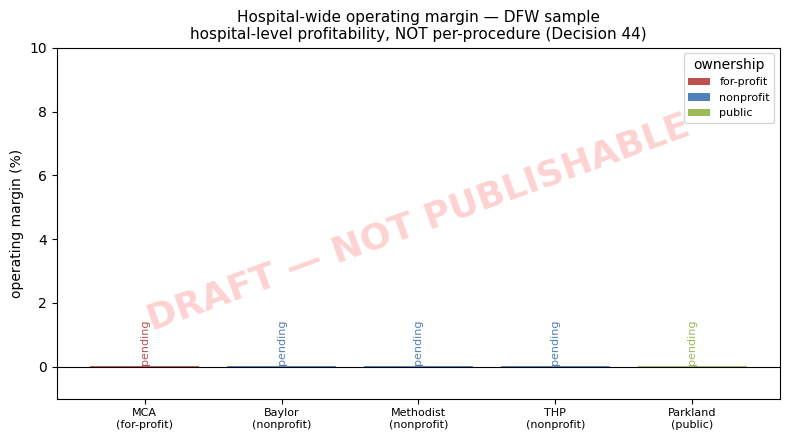

NB19 · Step V — chart rendered. real bars: 0/5 | watermark: ON
  title says 'hospital-wide operating margin' — never 'margin on 73721' (Decision 44).


In [7]:
# ── NB19 · Step V — Visualization (auto-watermarked) ──────────────────────────
require("is_publishable", hint="run Steps 0–S first")
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

OWNERSHIP_COLORS = {"for-profit": "#c0504d", "nonprofit": "#4f81bd", "public": "#9bbb59"}
_OWN_ORDER = {"for-profit": 0, "nonprofit": 1, "public": 2}

# order: real bars first (by ownership then margin), pending bars after
def _sort_key(short):
    r = REAL_MARGIN[short]; m = r["margin"]
    return (0 if not math.isnan(m) else 1, _OWN_ORDER[r["ownership"]],
            -(m if not math.isnan(m) else 0))
order = sorted(ROSTER, key=_sort_key)

fig, ax = plt.subplots(figsize=(8, 4.5))
xs = range(len(order))
for i, short in zip(xs, order):
    r = REAL_MARGIN[short]; m = r["margin"]; col = OWNERSHIP_COLORS[r["ownership"]]
    if math.isnan(m):                                    # pending -> hatched ghost, NOT zero
        ax.bar(i, 0.0, color="none", edgecolor=col, hatch="///", linewidth=1.3)
        ax.text(i, 0.05, "pending", ha="center", va="bottom", fontsize=8, color=col, rotation=90)
    else:
        ax.bar(i, m*100, color=col, edgecolor="black", linewidth=0.6)
        ax.text(i, m*100, f"{m*100:.1f}%", ha="center",
                va="bottom" if m >= 0 else "top", fontsize=9)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylim(-1, 10)                                      # widen once real values land
ax.set_xticks(list(xs))
ax.set_xticklabels([f"{s}\n({REAL_MARGIN[s]['ownership']})" for s in order], fontsize=8)
ax.set_ylabel("operating margin (%)")
ax.set_title("Hospital-wide operating margin — DFW sample\n"
             "hospital-level profitability, NOT per-procedure (Decision 44)", fontsize=11)
ax.legend(handles=[Patch(facecolor=c, label=o) for o, c in OWNERSHIP_COLORS.items()],
          fontsize=8, loc="upper right", title="ownership")

# watermark driven off is_publishable(): DRAFT for real-but-gated, [SYNTHETIC DATA] if tainted
if not is_publishable():
    taint = any(isinstance(r.get("source"), str) and "[SYNTHETIC" in r["source"]
                for r in REAL_MARGIN.values())
    wm = WATERMARK if taint else "DRAFT — NOT PUBLISHABLE"
    ax.text(0.5, 0.5, wm, transform=ax.transAxes, fontsize=26, color="red",
            alpha=0.18, ha="center", va="center", rotation=20, weight="bold")

plt.tight_layout()
plt.show()

n_real = sum(1 for r in REAL_MARGIN.values() if not math.isnan(r["margin"]))
print(f"NB19 · Step V — chart rendered. real bars: {n_real}/5 | "
      f"watermark: {'OFF' if is_publishable() else 'ON'}")
print("  title says 'hospital-wide operating margin' — never 'margin on 73721' (Decision 44).")

## Step F — Findings / handoff dict  `NB19_MARGIN`

Emit one JSON-friendly dict (`NaN`→`None`): per-hospital `{margin, basis, fiscal_year, source, ownership, corroborated, confirmed}` + top-level `publishable` flag + an **explicit `level: "hospital"` tag** + the proxy/label text for the app. **Handoff guard:** assert no record carries a CPT and that `publishable=False` while any value is unconfirmed. Include the do-not-publish block with the exact unblock recipe (auto-flips when the manual pull + line-confirm land). This is the profit-margin counterpart to `NB16_MARKUP`; the app shows the two lenses adjacent, never combined.


In [8]:
# ── NB19 · Step F — Findings / handoff dict  NB19_MARGIN ──────────────────────
require("is_publishable", hint="run Steps 0–V first")
import math, json

def _nan_to_none(x):
    if isinstance(x, float) and math.isnan(x): return None
    if isinstance(x, dict):  return {k: _nan_to_none(v) for k, v in x.items()}
    if isinstance(x, list):  return [_nan_to_none(v) for v in x]
    return x

# per-hospital records (hospital-level, operating-basis headline)
_hospitals = {}
for short, r in REAL_MARGIN.items():
    _hospitals[short] = _nan_to_none({
        "margin": r["margin"], "basis": r["basis"], "fiscal_year": r["fiscal_year"],
        "source": r["source"], "ownership": r["ownership"],
        "corroborated": r["corroborated"], "confirmed": r["confirmed"],
    })

NB19_MARGIN = {
    "factor": "profit_margin",
    "level": "hospital",                         # Decision 44: NEVER per-procedure
    "basis_headline": "operating",
    "publishable": is_publishable(),
    "label": ("Hospital-wide operating margin (HCRIS cost report; 990 cross-check "
              "for nonprofits). A profitability characterization of the whole "
              "hospital — NOT the profit on a 73721 knee MRI."),
    "sources": {sid: {k: s[k] for k in ("form", "keyed_by", "source_confirmed")}
                for sid, s in MARGIN_SOURCES.items()},
    "vintage": None,                             # per-hospital fiscal_year lives in each record
    "hospitals": _hospitals,
}

# ---- handoff guard -----------------------------------------------------------
for short, h in NB19_MARGIN["hospitals"].items():
    assert "cpt" not in h and "code" not in h, f"{short}: margin record carries a CPT (Decision 44)"
assert NB19_MARGIN["level"] == "hospital"
_filled = [h for h in NB19_MARGIN["hospitals"].values() if h["margin"] is not None]
if any(not h["confirmed"] for h in _filled) or not _filled:
    assert NB19_MARGIN["publishable"] is False, "publishable must be False while any value unconfirmed"

# ---- persist to the app boundary --------------------------------------------
out_path = OUTPUTS_DIR / "nb19_margin.json"
with open(out_path, "w") as f:
    json.dump(NB19_MARGIN, f, indent=2)

# ---- report ------------------------------------------------------------------
n_real = len(_filled)
print("NB19 · Step F — NB19_MARGIN handoff\n")
print(f"  {'Hospital':10} {'margin':>7} {'basis':10} {'conf':6} source")
print("  " + "-"*58)
for short, h in NB19_MARGIN["hospitals"].items():
    m = "  --" if h["margin"] is None else f"{h['margin']*100:.1f}%"
    print(f"  {short:10} {m:>7} {str(h['basis']):10} {str(h['confirmed']):6} {h['source']}")
print(f"\n  real margins    : {n_real}/5")
print(f"  publishable     : {NB19_MARGIN['publishable']}")
print(f"  persisted       : {out_path}")

if not NB19_MARGIN["publishable"]:
    print("\n  ── DO NOT PUBLISH ──────────────────────────────────────────────")
    print("  Unblock recipe (auto-flips publishable=True when done):")
    print("    1. Manual-pull HCRIS G-3/G-2 dollars for the five CCNs -> REAL_INPUTS (Step R)")
    print("    2. Eyeball G-3 L3 / G-2 L43 vs the cost-report layout -> HCRIS source_confirmed=True")
    print("    3. (nonprofits) paste 990 Schedule H margin -> reconcile agrees")
    print("    4. MARGINS_PUBLISHABLE=True -> Restart & Run All")
    print("  ────────────────────────────────────────────────────────────────")

NB19 · Step F — NB19_MARGIN handoff

  Hospital    margin basis      conf   source
  ----------------------------------------------------------
  Baylor          -- None       False  None
  Methodist       -- None       False  None
  Parkland        -- None       False  None
  MCA             -- None       False  None
  THP             -- None       False  None

  real margins    : 0/5
  publishable     : False
  persisted       : C:\Users\kedha\Documents\dfw-hospital-pricing\outputs\nb19_margin.json

  ── DO NOT PUBLISH ──────────────────────────────────────────────
  Unblock recipe (auto-flips publishable=True when done):
    1. Manual-pull HCRIS G-3/G-2 dollars for the five CCNs -> REAL_INPUTS (Step R)
    2. Eyeball G-3 L3 / G-2 L43 vs the cost-report layout -> HCRIS source_confirmed=True
    3. (nonprofits) paste 990 Schedule H margin -> reconcile agrees
    4. MARGINS_PUBLISHABLE=True -> Restart & Run All
  ────────────────────────────────────────────────────────────────


## Step I — Integrity sweep

Collect-all-failures guards: roster completeness · no-synthetic-leak · **conflation guard (no margin record carries a CPT)** · basis is labeled on every record · HCRIS↔990 reconciled-or-flagged for nonprofits · publish-state consistency (`publishable` matches `confirmed` reality) · margin sanity (plausible range, sign correct). Close with `Integrity: OK` = *correctly gated*, **not** ship-ready — the NB17/NB18 discipline.


In [9]:
# ── NB19 · Step I — Integrity sweep ───────────────────────────────────────────
require("NB19_MARGIN", hint="run Steps 0–F first")
import math

failures = []
def guard(name, ok, detail=""):
    print(f"  {'✓' if ok else '✗'} {name}" + (f"  — {detail}" if (not ok and detail) else ""))
    if not ok:
        failures.append(f"{name}: {detail}" if detail else name)

print("NB19 · Step I — integrity sweep\n")

# G1 roster completeness
guard("G1 roster complete",
      set(REAL_MARGIN) == set(ROSTER) and set(NB19_MARGIN["hospitals"]) == set(ROSTER))

# G2 no synthetic leak into the real payload
_leak = [s for s, r in REAL_MARGIN.items()
         if isinstance(r.get("source"), str) and "[SYNTHETIC" in r["source"]]
guard("G2 no synthetic leak", not _leak, str(_leak))

# G3 conflation guard (Decision 44): hospital-level, no CPT anywhere
_conf = []
for s, r in REAL_MARGIN.items():
    if r.get("level") != "hospital": _conf.append((s, "level"))
    if any(k in r for k in FORBIDDEN_PROC_KEYS): _conf.append((s, "cpt"))
for s, h in NB19_MARGIN["hospitals"].items():
    if any(k in h for k in FORBIDDEN_PROC_KEYS): _conf.append((s, "cpt-handoff"))
guard("G3 conflation guard (D44)", not _conf, str(_conf))

# G4 basis labeled on every FILLED record
_bad = [s for s, r in REAL_MARGIN.items()
        if not math.isnan(r["margin"]) and r["basis"] not in VALID_BASES]
guard("G4 basis labeled", not _bad, str(_bad))

# G5 reconcile-or-flagged: no silent HCRIS<->990 mismatch while publishable
_mismatch = [s for s, v in (recon_real.items() if "recon_real" in globals() else [])
             if v == "mismatch"]
guard("G5 no silent HCRIS/990 mismatch while publishable",
      not (_mismatch and NB19_MARGIN["publishable"]), str(_mismatch))

# G6 publish-state consistency
_filled = [r for r in REAL_MARGIN.values() if not math.isnan(r["margin"])]
ok6 = (NB19_MARGIN["publishable"] == is_publishable())
if any(not r["confirmed"] for r in _filled) or not _filled:
    ok6 = ok6 and (NB19_MARGIN["publishable"] is False)
guard("G6 publish-state consistent", ok6)

# G7 margin sanity: filled margins within a plausible band
_wild = [(s, r["margin"]) for s, r in REAL_MARGIN.items()
         if not math.isnan(r["margin"]) and not (-0.5 <= r["margin"] <= 0.5)]
guard("G7 margin sanity (±50%)", not _wild, str(_wild))

# ---- verdict -----------------------------------------------------------------
print()
if failures:
    raise AssertionError(f"NB19 integrity: {len(failures)} failure(s): {failures}")
n_real = len(_filled)
print(f"Integrity: OK — 5 hospitals · {n_real} real · {5 - n_real} pending · "
      f"MARGINS_PUBLISHABLE={NB19_MARGIN['publishable']}")
print("  (OK = correctly gated, NOT ship-ready: 0/5 real pending the manual HCRIS/990 pull.)")

NB19 · Step I — integrity sweep

  ✓ G1 roster complete
  ✓ G2 no synthetic leak
  ✓ G3 conflation guard (D44)
  ✓ G4 basis labeled
  ✓ G5 no silent HCRIS/990 mismatch while publishable
  ✓ G6 publish-state consistent
  ✓ G7 margin sanity (±50%)

Integrity: OK — 5 hospitals · 0 real · 5 pending · MARGINS_PUBLISHABLE=False
  (OK = correctly gated, NOT ship-ready: 0/5 real pending the manual HCRIS/990 pull.)
